In [2]:
# ======================================
# SmogNet EDA Notebook
# ======================================

from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

spark = SparkSession.builder.getOrCreate()

df=spark.sql(
"""
SELECT *
FROM Silver_training
"""
).toPandas()

print(df.shape)

df.head()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 5, Finished, Available, Finished, False)

(264335, 43)


,datetime,main_aqi,components_co,components_no,components_no2,components_o3,components_so2,components_pm2_5,components_pm10,components_nh3,...,components_no2_roll_mean,components_no2_roll_std,components_pm2_5_lag1,components_pm2_5_lag24,components_pm10_lag1,components_pm10_lag24,PM10_PM25_ratio,NO2_NO_ratio,SO2_CO_ratio,severity_score
0,11/20/2023 17:00,4,1174.93,0.01,46.61,32.54,6.74,67.23,95.19,17.23,...,30.396667,18.349717,68.86,66.17,96.71,97.41,1.415886,4661.0,0.005737,56.649
1,11/20/2023 18:00,4,1054.76,0.01,38.39,34.69,5.84,63.96,91.92,15.83,...,29.854167,17.888117,67.23,71.72,95.19,103.42,1.437148,3839.0,0.005537,54.360
2,11/20/2023 19:00,4,881.20,0.00,29.82,39.70,4.59,56.14,83.40,12.67,...,29.040417,17.400237,63.96,71.56,91.92,103.13,1.485572,0.0,0.005209,48.676
3,11/20/2023 20:00,3,694.27,0.00,20.91,48.64,3.61,49.12,75.51,9.88,...,28.026667,17.121918,56.14,68.87,83.40,100.74,1.537256,0.0,0.005200,43.201
4,11/20/2023 21:00,3,567.44,0.00,14.22,57.94,3.16,45.78,72.05,8.49,...,27.019583,17.196519,49.12,64.49,75.51,96.24,1.573831,0.0,0.005569,40.827


In [3]:
print("Shape")

print(df.shape)


StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 6, Finished, Available, Finished, False)

Shape
(264335, 43)


In [4]:
print("\nColumns")

print(df.columns)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 7, Finished, Available, Finished, False)


Columns
Index(['datetime', 'main_aqi', 'components_co', 'components_no',
       'components_no2', 'components_o3', 'components_so2', 'components_pm2_5',
       'components_pm10', 'components_nh3', 'temperature_2m',
       'relative_humidity_2m', 'dew_point_2m', 'precipitation',
       'surface_pressure', 'wind_speed_10m', 'wind_direction_10m',
       'shortwave_radiation', 'dataset_type', 'source_file', 'parsed_datetime',
       'hour', 'day', 'month', 'year', 'weekday', 'weekofyear', 'is_weekend',
       'season', 'components_pm2_5_roll_mean', 'components_pm2_5_roll_std',
       'components_pm10_roll_mean', 'components_pm10_roll_std',
       'components_no2_roll_mean', 'components_no2_roll_std',
       'components_pm2_5_lag1', 'components_pm2_5_lag24',
       'components_pm10_lag1', 'components_pm10_lag24', 'PM10_PM25_ratio',
       'NO2_NO_ratio', 'SO2_CO_ratio', 'severity_score'],
      dtype='object')


In [5]:

print("\nData Types")

print(df.dtypes)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 8, Finished, Available, Finished, False)


Data Types
datetime                              object
main_aqi                               int64
components_co                        float64
components_no                        float64
components_no2                       float64
components_o3                        float64
components_so2                       float64
components_pm2_5                     float64
components_pm10                      float64
components_nh3                       float64
temperature_2m                       float64
relative_humidity_2m                 float64
dew_point_2m                         float64
precipitation                        float64
surface_pressure                     float64
wind_speed_10m                       float64
wind_direction_10m                   float64
shortwave_radiation                    int64
dataset_type                          object
source_file                           object
parsed_datetime               datetime64[us]
hour                                   int3

In [6]:
print("\nMissing Values")

print(
df.isnull().sum()
)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 9, Finished, Available, Finished, False)


Missing Values
datetime                      0
main_aqi                      0
components_co                 0
components_no                 0
components_no2                0
components_o3                 0
components_so2                0
components_pm2_5              0
components_pm10               0
components_nh3                0
temperature_2m                0
relative_humidity_2m          0
dew_point_2m                  0
precipitation                 0
surface_pressure              0
wind_speed_10m                0
wind_direction_10m            0
shortwave_radiation           0
dataset_type                  0
source_file                   0
parsed_datetime               0
hour                          0
day                           0
month                         0
year                          0
weekday                       0
weekofyear                    0
is_weekend                    0
season                        0
components_pm2_5_roll_mean    0
components_pm2_5_roll_st

In [7]:
pollutants=[

"components_pm2_5",
"components_pm10",
"components_no",
"components_no2",
"components_o3",
"components_so2",
"components_nh3",
"components_co"

]

for c in pollutants:

    df[c]=pd.to_numeric(
        df[c],
        errors="coerce"
    )

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 10, Finished, Available, Finished, False)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 11, Finished, Available, Finished, False)

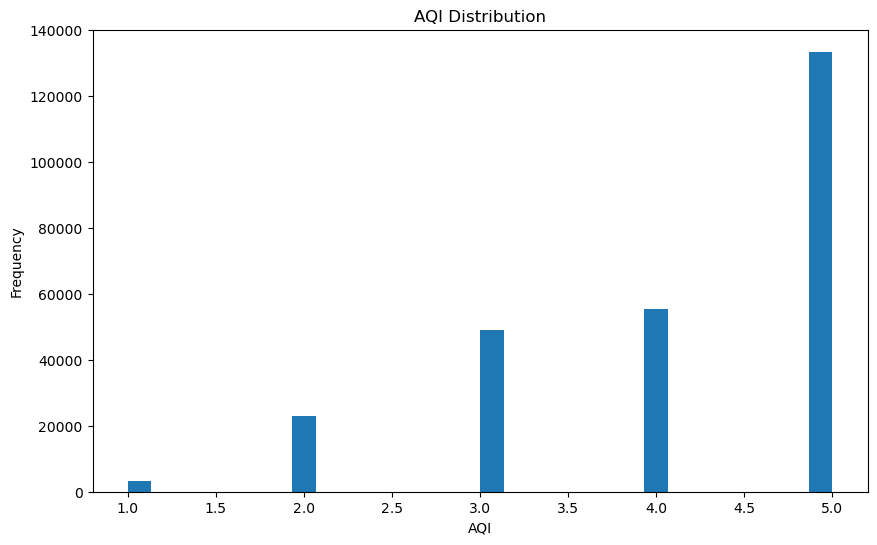

In [8]:
plt.figure(figsize=(10,6))

plt.hist(
    df["main_aqi"].dropna(),
    bins=30
)

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.title("AQI Distribution")

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 12, Finished, Available, Finished, False)

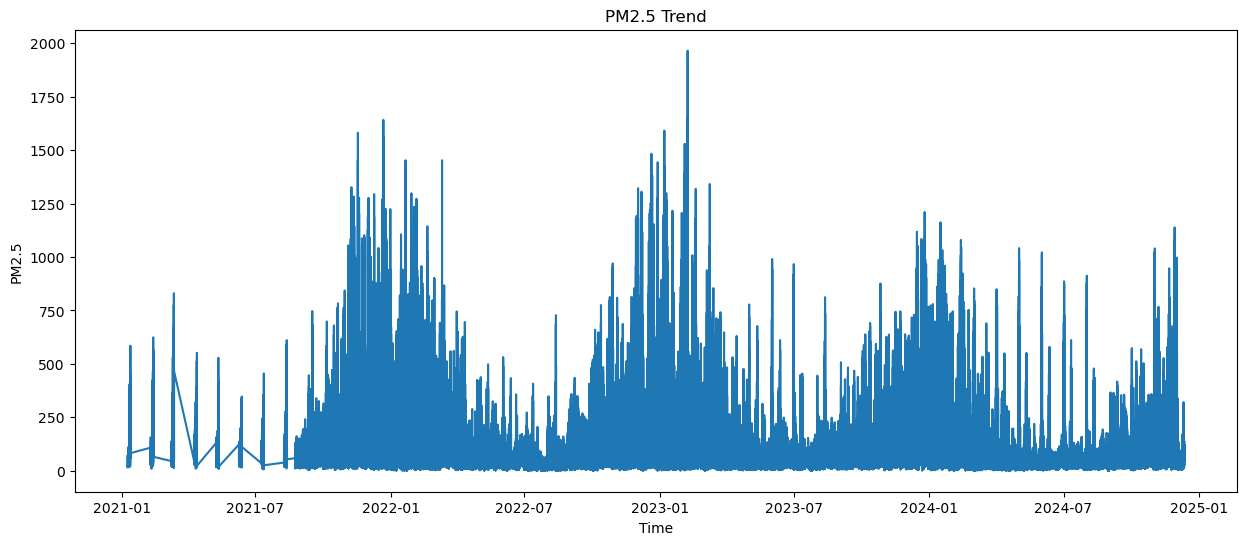

In [9]:
df=df.sort_values(
    "parsed_datetime"
)

plt.figure(figsize=(15,6))

plt.plot(
    df["parsed_datetime"],
    df["components_pm2_5"]
)

plt.xlabel("Time")

plt.ylabel("PM2.5")

plt.title(
"PM2.5 Trend"
)

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 13, Finished, Available, Finished, False)

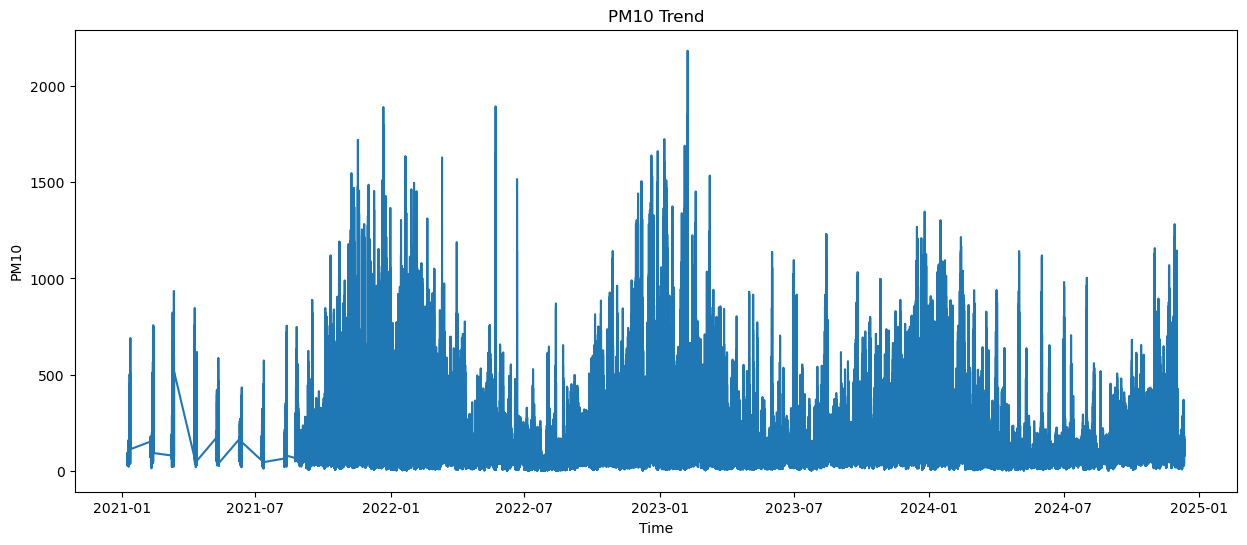

In [10]:
plt.figure(figsize=(15,6))

plt.plot(
df["parsed_datetime"],
df["components_pm10"]
)

plt.xlabel("Time")

plt.ylabel("PM10")

plt.title(
"PM10 Trend"
)

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 14, Finished, Available, Finished, False)

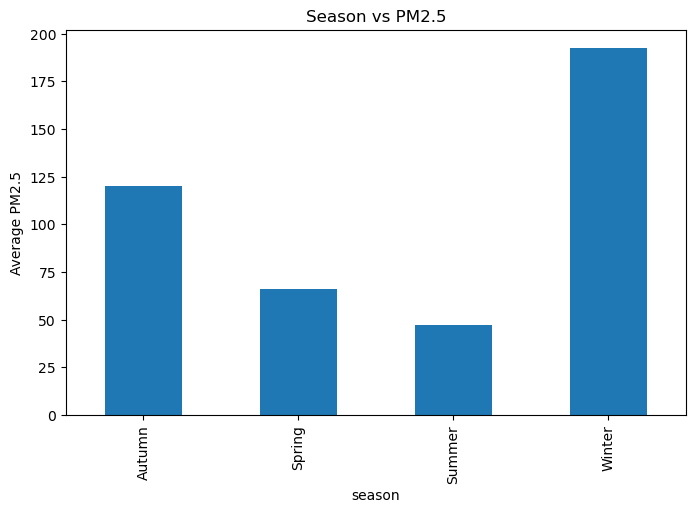

In [11]:
season_pm=df.groupby(
"season"
)[
"components_pm2_5"
].mean()

plt.figure(figsize=(8,5))

season_pm.plot(
kind="bar"
)

plt.ylabel(
"Average PM2.5"
)

plt.title(
"Season vs PM2.5"
)

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 15, Finished, Available, Finished, False)

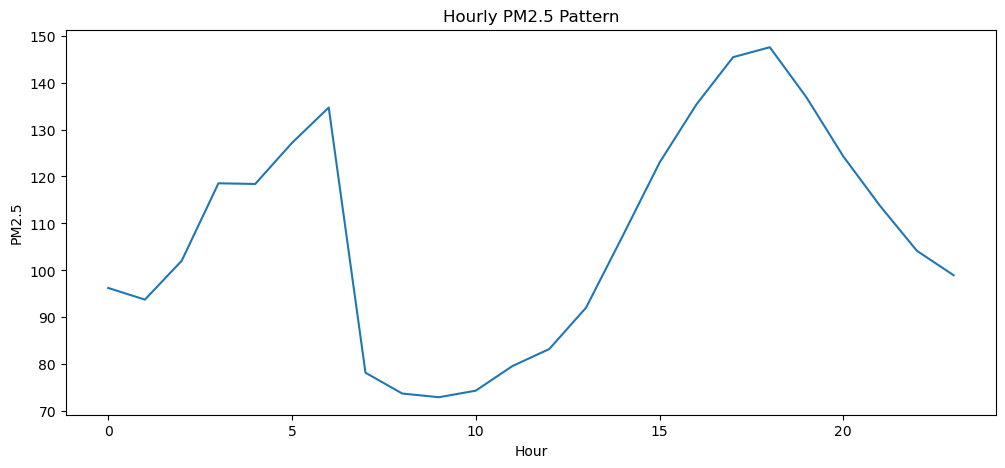

In [12]:
hourly=df.groupby(
"hour"
)[
"components_pm2_5"
].mean()

plt.figure(figsize=(12,5))

plt.plot(
hourly.index,
hourly.values
)

plt.xlabel(
"Hour"
)

plt.ylabel(
"PM2.5"
)

plt.title(
"Hourly PM2.5 Pattern"
)

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 16, Finished, Available, Finished, False)

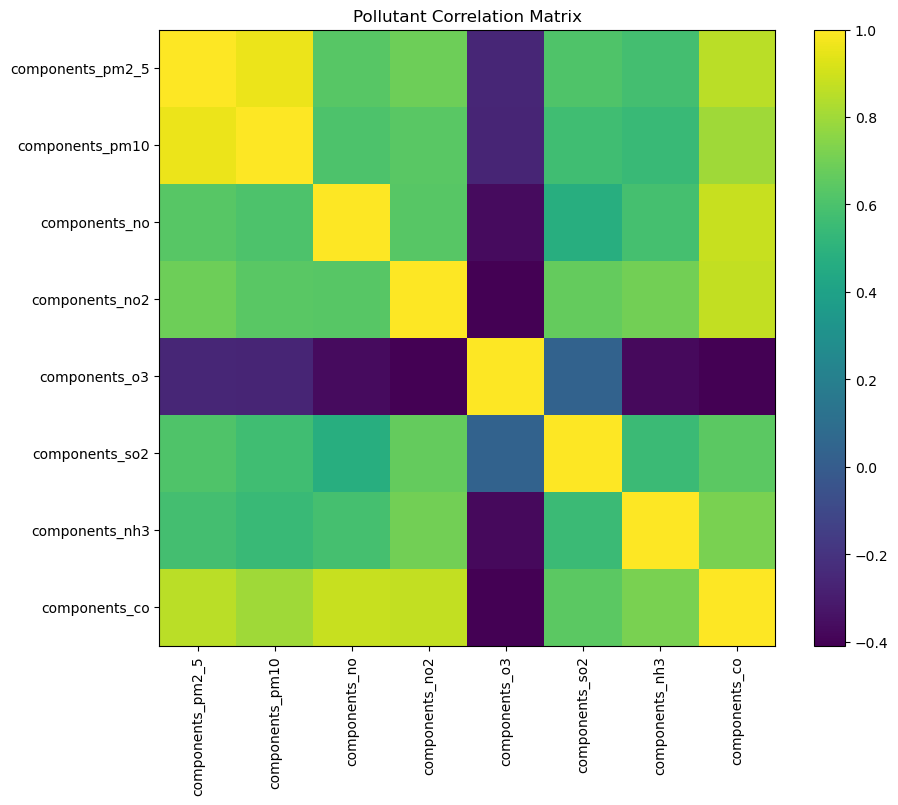

In [13]:
corr=df[pollutants].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar()

plt.title("Pollutant Correlation Matrix")

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 17, Finished, Available, Finished, False)

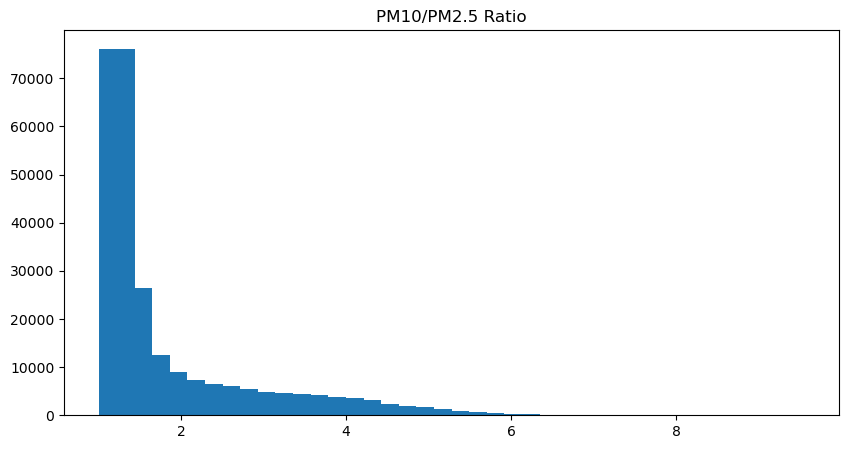

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
df[
"PM10_PM25_ratio"
].dropna(),
bins=40
)

plt.title(
"PM10/PM2.5 Ratio"
)

plt.show()

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 18, Finished, Available, Finished, False)

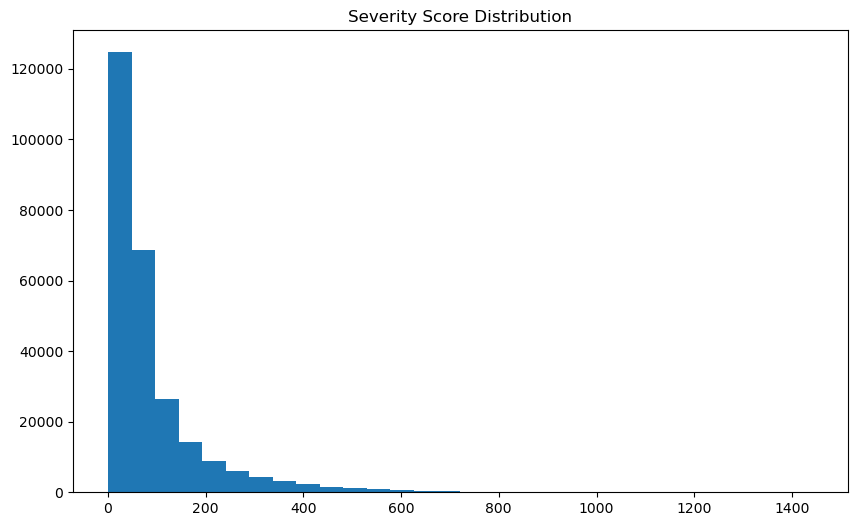

In [15]:
plt.figure(figsize=(10,6))

plt.hist(
df[
"severity_score"
].dropna(),
bins=30
)

plt.title(
"Severity Score Distribution"
)

plt.show()

In [16]:
print(
"Average PM2.5:",
df[
"components_pm2_5"
].mean()
)

print(
"Highest AQI:",
df[
"main_aqi"
].max()
)

print(
"Average PM10:",
df[
"components_pm10"
].mean()
)

print(
"Average Severity:",
df[
"severity_score"
].mean()
)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 19, Finished, Available, Finished, False)

Average PM2.5: 107.57391870164753
Highest AQI: 5
Average PM10: 150.39033018707323
Average Severity: 89.37839559271377


In [17]:
import re

def get_city(x):

    x=x.lower()

    if "lahore" in x:
        return "Lahore"

    elif "karachi" in x:
        return "Karachi"

    elif "islamabad" in x:
        return "Islamabad"

    elif "peshawar" in x:
        return "Peshawar"

    elif "quetta" in x:
        return "Quetta"

    return "Unknown"


df["city"]=df[
"source_file"
].apply(
get_city
)

print(
df["city"].value_counts()
)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 20, Finished, Available, Finished, False)

city
Unknown      123134
Lahore        28269
Peshawar      28245
Islamabad     28245
Quetta        28221
Karachi       28221
Name: count, dtype: int64


In [18]:
spark.createDataFrame(
df
).write.mode(
"overwrite"
).format(
"delta"
).saveAsTable(
"EDA_dataset"
)

StatementMeta(, 6df721ca-9d14-4cca-904e-35ec31e59c88, 21, Finished, Available, Finished, False)